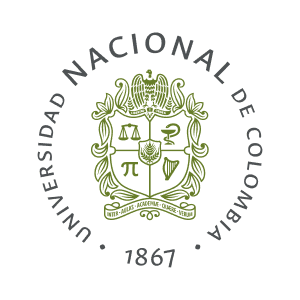

# Proyecto NLP

## Título:
Similitudes y Conexiones entre Papers

## Estudiantes:
- Angel David Pineros Sierra
- Miller Estiven Barrera Gonzalez
- Juan David Rodriguez Gomez
- Fabio Esteban Murcia Martínez

## Repositorio del Proyecto:
[https://github.com/mbarrerag/NLP-Dataset.git](https://github.com/mbarrerag/NLP-Dataset.git)

In [37]:
import pandas as pd
import os

# Clone the GitHub repository
!git clone https://github.com/mbarrerag/NLP-Dataset.git

fatal: destination path 'NLP-Dataset' already exists and is not an empty directory.


In [1]:
import re, json, html, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display


In [ ]:
# Define necessary variables for the cleaning process
from pathlib import Path

DATASET_NAME = 'HORUS_Bogota_Ingenieria_Ingles.xlsx'
DATASET_CANDIDATES = [
    Path('data/raw') / DATASET_NAME,
    Path('NLP-Dataset/data/raw') / DATASET_NAME,
    Path('NLP-Dataset') / DATASET_NAME,
]
dataset_path = next((path for path in DATASET_CANDIDATES if path.is_file()), DATASET_CANDIDATES[0])
if not dataset_path.is_file():
    raise FileNotFoundError(f'Dataset not found. Checked: {DATASET_CANDIDATES}')

SIMILARITY_METHOD = 'tfidf'
OUTPUT_DIR = 'output'
INPUT_FILE = dataset_path
SHEET_NAME = None

In [3]:
# Load the dataset using the configured file path and worksheet
sheet = 0 if SHEET_NAME is None else SHEET_NAME
df = pd.read_excel(INPUT_FILE, sheet_name=sheet)
print(f"Successfully loaded dataset from: {INPUT_FILE}")
display(df.head(10))

Successfully loaded dataset from: NLP-Dataset\HORUS_Bogota_Ingenieria.xlsx


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
0,Post-harvest evaluation of the effect of folia...,NaN,Plant Signaling & Behavior,"Florez Roncancio Victor Julio, Darghan Contrer...",10.1080/15592324.2025.2465234,NaN,15592316,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
1,Prebiotic potential of cocoa bean shells in fo...,NaN,Cogent Food & Agriculture,"Botina Azain Blanca Lucia, Montoya Campuzano O...",10.1080/23311932.2025.2536915,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
2,Exploring microbial soil communities structure...,NaN,Cogent Food & Agriculture,"Saavedra Correa, Juan David, Aristizabal Gutie...",10.1080/23311932.2025.2548928,NaN,23311932,0.0,Inglés,31/12/2025,Artículo de revista,WEB OF SCIENCE,https://www.webofscience.com/wos/woscc/full-re...
3,Recent advances in solvent development for car...,"The practices of carbon capture, storage, and ...",Separation and Purification Technology,"Vargas Sáenz Julio Cesar, Castro Juan Jose, Qu...",10.1016/j.seppur.2025.134962,NaN,"13835866, 18733794",1.0,Inglés,31/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
4,Effect of the conformation of a diazoted-resor...,"In the present work, a mono-diazoted resorcin[...",Journal of Molecular Structure,"Maldonado Villamil Mauricio, López Mónica, Est...",10.1016/j.molstruc.2025.143311,NaN,00222860,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
5,Study of Tm3+ incorporation in TiO2 coatings f...,"In this work, the synthesis and characterizati...",Applied Surface Science,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.1016/j.apsusc.2025.164338,NaN,01694332,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
6,Tuning confined states in Si1−xGex photonic ca...,"In this work, using the transfer matrix method...","Physica . B , Condensed Matter","Vinck Posada Herbert, Francis Segovia Chaves, ...",10.1016/j.physb.2025.417984,NaN,09214526,0.0,Inglés,15/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.1016/j.physb.2025.417984...
7,The NW-Amazonian Craton in Colombia: A Paleo-M...,The geological evolution of the NW-Amazonian C...,Journal of South American Earth Sciences,"Cramer Thomas Heinrich, Amed Bonilla, Hernánde...",10.1016/j.jsames.2025.105806,NaN,08959811,0.0,Inglés,15/12/2025,Estado del arte,SCOPUS,https://dx.doi.org/10.1016/j.jsames.2025.10580...
8,Scientometric analysis of computational calcul...,The rapid industrialization has driven economi...,Global Journal of Environmental Science and Ma...,"Torres Ceron Darwin Augusto, Restrepo Parra El...",10.22034/gjesm.2025.01.18,NaN,"23833866, 23833572",1.0,Inglés,01/12/2025,Artículo de revista,SCOPUS,https://dx.doi.org/10.22034/gjesm.2025.01.18 ...
9,Transition clinics in pediatric rheumatology i...,Introduction: Transition clinics are conceived...,Advances in Rheumatology,"Quintana López Gerardo, Ramirez Lauren Natalia...",10.1186/s42358-024-00419-2,NaN,25233106,0.0,Inglés,01/12/2025,Estado del arte,SCOPUS,https://www.scopus.com/inward/record.uri?partn...


#Columas del dataset

*   **`paper_id`**: Un identificador único generado para cada registro, comenzando con `HORUS_` seguido de un número secuencial.
*   **`title_normalized`**: Una versión normalizada del `Título original`, convertida a minúsculas y limpiada de caracteres especiales.
*   **`abstract_clean`**: Una versión limpia de la `Descripción original` (abstract), donde se eliminan etiquetas HTML y se normaliza el espacio en blanco.
*   **`abstract_status`**: Indica si el abstract está presente (`PRESENT`) o si falta (`MISSING_ABSTRACT`).
*   **`journal_normalized`**: Una versión limpia de la columna `Revista / Conferencia`.
*   **`doi_normalized`**: El DOI (Digital Object Identifier) de la publicación, extraído y normalizado para asegurar un formato consistente.
*   **`issn_normalized`**: El ISSN (International Standard Serial Number) de la publicación, extraído y normalizado.
*   **`language_iso639_1`** o **`idioma normalizado`**: El idioma de la publicación, mapeado a su código ISO 639-1 (ej., `en` para inglés, `es` para español). Si el idioma no se reconoce, se etiqueta como `und` (undetermined) o el texto original en mayúsculas.
*   **`document_type_normalized`**: El tipo de documento (ej., `JOURNAL_ARTICLE`, `CONFERENCE_PAPER`), normalizado a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `OTHER`.
*   **`source_normalized`**: La fuente de la publicación (ej., `WEB_OF_SCIENCE`, `SCOPUS`), normalizada a un conjunto de categorías predefinidas. Si no se reconoce, se etiqueta como `UNKNOWN`.
*   **`publication_date`**: La fecha de publicación, convertida al formato `YYYY-MM-DD`.
*   **`publication_year`**: El año de publicación, extraído de la fecha de publicación.
*   **`citations_normalized`**: El número de citaciones, convertido a formato numérico entero y con valores faltantes llenados con 0.
*   **`authors_normalized`**: Una lista de autores, donde los nombres se limpian y se separan adecuadamente.
*   **`authors_normalized_text`**: Una cadena de texto que concatena los autores normalizados, separados por ` | `.
*   **`text_for_nlp`**: Un campo combinado del título normalizado y el abstract limpio, diseñado para ser utilizado en tareas de procesamiento de lenguaje natural (NLP).
*   **`labels`**: Un diccionario que contiene etiquetas categóricas extraídas automáticamente (como `research_area`, `topics`, `methods`, `data_types`, `metrics`) para cada artículo, basado en la taxonomía definida.

## Valores nulos

In [41]:
# Contar los valores nulos iniciales en el DataFrame 'df' (el DataFrame original cargado)
print("Valores nulos por columna en el DataFrame inicial:")
display(df.isnull().sum())

Valores nulos por columna en el DataFrame inicial:


Título original              0
Descripción original      1478
Revista / Conferencia     6754
Coautores                    0
Doi                      13846
ISBN                     23331
ISSN                     13568
Citaciones                1496
Idioma                     180
Fecha                        0
Tipo                         0
Fuente                       0
Enlace                   10701
dtype: int64

## Posibles duplicados

In [4]:
# Encontrar y eliminar registros con el mismo 'Título original', 'Descripción original' y 'Fecha'
duplicate_subset = ['Título original', 'Descripción original', 'Fecha']
duplicate_mask = df.duplicated(subset=duplicate_subset, keep=False)
duplicate_titles_abstracts = df.loc[duplicate_mask].copy()

if not duplicate_titles_abstracts.empty:
    print(f"Se encontraron {len(duplicate_titles_abstracts)} registros que pertenecen a grupos duplicados:")
    display(duplicate_titles_abstracts.sort_values(by=duplicate_subset))
    rows_before = len(df)
    df = df.drop_duplicates(subset=duplicate_subset, keep='first').copy()
    print(f"Se eliminaron {rows_before - len(df)} duplicados; quedan {len(df)} registros.")
else:
    print("No se encontraron registros duplicados.")

Se encontraron 50 registros que pertenecen a grupos duplicados:


,Título original,Descripción original,Revista / Conferencia,Coautores,Doi,ISBN,ISSN,Citaciones,Idioma,Fecha,Tipo,Fuente,Enlace
21148,Colombia 2023: International Conference on Mar...,--,NaN,"Osorio Arias Andres Fernando, Ballantyne Puin ...",NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
21217,Colombia 2023: International Conference on Mar...,--,NaN,Zea Sjoberg Sven Eloy,NaN,NaN,NaN,NaN,Inglés,01/01/2022,Proyecto,HERMES,NaN
17430,EDITORIAL,NaN,Revista de la Facultad de Ciencias ( Medellín ...,"Lopez Rios Victor Ignacio, Montoya, José A.",NaN,NaN,"0121747X, 23575549",0.0,NaN,01/07/2022,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/rfc/art...
17449,EDITORIAL,NaN,Revista de la Facultad de Ciencias ( Medellín ...,"Lopez Rios Victor Ignacio, Montoya, José A.",NaN,NaN,"0121747X, 23575549",0.0,NaN,01/07/2022,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
20379,Editorial,NaN,Revista Colombiana de Estadística,Giraldo Henao Ramon,NaN,NaN,"23898976, 01201751",0.0,Indonesio,01/01/2022,Artículo de revista,RevistasUNAL,https://revistas.unal.edu.co/index.php/estad/a...
20423,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/historelo.v14n29.98802,NaN,2145132X,0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://dx.doi.org/10.15446/historelo.v14n29.9...
20424,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/HISTORELO.V14N29.98802,NaN,2145132X,0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
20556,Editorial,NaN,Revista Innovar Journal,Castañeda Rodriguez Victor Mauricio,10.15446/INNOVAR.V32N83.100245,NaN,"01215051, 22486968",0.0,Indonesio,01/01/2022,Editorial,SCOPUS,https://dx.doi.org/10.15446/INNOVAR.V32N83.100...
13063,Editorial,NaN,Historelo Revista de História Regional y Local,Ramirez Bacca Renzo,10.15446/historelo,NaN,2145132X,0.0,Indonesio,01/01/2023,Editorial,SCOPUS,https://www.scopus.com/inward/record.uri?partn...
13181,Editorial,NaN,Revista Innovar Journal,Castañeda Rodriguez Victor Mauricio,10.15446/innovar.v33n88.108077,NaN,"01215051, 22486968",0.0,Indonesio,01/01/2023,Editorial,SCOPUS,https://dx.doi.org/10.15446/innovar.v33n88.108...


Se eliminaron 28 duplicados; quedan 24972 registros.


## 1. Limpieza bibliográfica

Conservamos las columnas originales y añadimos campos normalizados. Los abstracts vacíos se marcan; nunca se inventa contenido.

In [5]:
Path(OUTPUT_DIR).mkdir(exist_ok=True)

def clean_text(x, lower=False):
    if pd.isna(x): return ''
    x = re.sub(r'<[^>]+>', ' ', html.unescape(str(x)))
    x = re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', x)).strip()
    return x.lower() if lower else x
def norm_doi(x):
    x = re.sub(r'^(https?://(dx\.)?doi\.org/|doi:\s*)', '', clean_text(x, True))
    m = re.search(r'10\.\d{4,9}/[-._;()/:a-z0-9]+', x)
    return m.group(0).rstrip('.,;)') if m else ''
def norm_issn(x):
    d = re.sub(r'[^0-9Xx]', '', clean_text(x).replace('.0','')).upper()
    return f'{d[:4]}-{d[4:]}' if len(d) == 8 else clean_text(x)
LANG={'inglés':'en','ingles':'en','english':'en','español':'es','espanol':'es','spanish':'es','portugués':'pt','portugues':'pt','portuguese':'pt','francés':'fr','frances':'fr','french':'fr','alemán':'de','aleman':'de','german':'de','italiano':'it','catalán':'ca','galicia':'gl','vasco':'eu','indonesio':'id'}
TYPE={'artículo de revista':'JOURNAL_ARTICLE','articulo de revista':'JOURNAL_ARTICLE','artículo de conferencia':'CONFERENCE_PAPER','articulo de conferencia':'CONFERENCE_PAPER','ponencias en eventos especializados':'CONFERENCE_PRESENTATION','capítulo de libro':'BOOK_CHAPTER','capitulo de libro':'BOOK_CHAPTER','libro':'BOOK','tesis maestría':'MASTER_THESIS','tesis doctorado':'DOCTORAL_THESIS','tesis especialización':'SPECIALIZATION_THESIS','estado del arte':'LITERATURE_REVIEW','preimpresión':'PREPRINT','preimpresion':'PREPRINT','patente':'PATENT','proyecto':'PROJECT','editorial':'EDITORIAL','formato audiovisual':'AUDIOVISUAL'}
SOURCE={'web of science':'WEB_OF_SCIENCE','wos':'WEB_OF_SCIENCE','scopus':'SCOPUS','pubmed':'PUBMED','scielo':'SCIELO','repositoriounal':'REPOSITORIO_UNAL','revistasunal':'REVISTAS_UNAL','bibliotecasunal':'BIBLIOTECAS_UNAL','sara':'SARA','hermes':'HERMES'}
def norm_map(x, mapping, empty):
    k=clean_text(x,True); return mapping.get(k, empty if not k else k.upper().replace(' ','_'))
def parse_authors(x):
    raw=clean_text(x)
    if not raw:return []
    parts=[clean_text(a) for a in (raw.split(';') if ';' in raw else raw.split(','))] # Changed to handle multiple delimiters
    out=[];i=0
    while i<len(parts):
        a=parts[i]
        if a and len(a.split())==1 and i+1<len(parts): a=f'{a}, {parts[i+1]}';i+=1
        if a:out.append(a)
        i+=1
    return out

raw = df.copy()
expected={'Título original','Descripción original','Revista / Conferencia','Coautores','Doi','ISSN','Citaciones','Idioma','Fecha','Tipo','Fuente','Enlace'}
if missing:=expected-set(raw.columns):raise ValueError(f'Faltan: {sorted(missing)}')
papers=raw.copy();papers.insert(0,'paper_id',[f'HORUS_{i:06d}' for i in range(1,len(papers)+1)])

# Eliminar la columna 'Doi ISBN'
papers = papers.drop(columns=['Doi ISBN'], errors='ignore')
# Eliminar la columna 'ISBN'
papers = papers.drop(columns=['ISBN'], errors='ignore')

papers['title_normalized']=papers['Título original'].map(lambda x:clean_text(x,True));papers['abstract_clean']=papers['Descripción original'].map(clean_text)
papers['abstract_status']=np.where(papers.abstract_clean.eq(''),'MISSING_ABSTRACT','PRESENT');papers['journal_normalized']=papers['Revista / Conferencia'].map(clean_text)
papers['doi_normalized']=papers.Doi.map(norm_doi);papers['issn_normalized']=papers.ISSN.map(norm_issn);papers['language_iso639_1']=papers.Idioma.map(lambda x:LANG.get(clean_text(x,True),'und' if not clean_text(x,True) else clean_text(x,True)))
papers['Idioma original'] = papers['Idioma']
papers = papers.drop(columns=['Idioma'], errors='ignore')
papers['document_type_normalized']=papers.Tipo.map(lambda x:norm_map(x,TYPE,'OTHER'));papers['source_normalized']=papers.Fuente.map(lambda x:norm_map(x,SOURCE,'UNKNOWN'))
date=pd.to_datetime(papers.Fecha,dayfirst=True,errors='coerce');papers['publication_date']=date.dt.strftime('%Y-%m-%d').fillna('');papers['publication_year']=date.dt.year.astype('Int64')
papers['citations_normalized']=pd.to_numeric(papers.Citaciones,errors='coerce').fillna(0).astype(int);papers['authors_normalized']=papers.Coautores.map(parse_authors);papers['authors_normalized_text']=papers.authors_normalized.map(' | '.join)
papers['text_for_nlp']=(papers.title_normalized+'. '+papers.abstract_clean.map(lambda x:clean_text(x,True))).str.strip('. ')
papers['dedup_key']=np.where(papers.doi_normalized.ne(''),'DOI:'+papers.doi_normalized,'TITLE_YEAR:'+papers.title_normalized+'|'+papers.publication_year.astype(str));papers['duplicate_group']=papers.groupby('dedup_key',sort=False).ngroup().map(lambda x:f'DUP_{x:06d}');papers['is_duplicate']=papers.duplicated('dedup_key',keep='first')
print(f'Registros: {len(papers):,} | Sin resumen: {papers.abstract_status.eq("MISSING_ABSTRACT").sum():,} | Duplicados: {papers.is_duplicate.sum():,}')
papers = papers.drop(columns=['is_duplicate'], errors='ignore')
papers = papers.drop(columns=['dedup_key', 'duplicate_group'], errors='ignore')
display(papers[['paper_id','Título original','doi_normalized','language_iso639_1','document_type_normalized','abstract_status']].head())

Registros: 24,972 | Sin resumen: 1,461 | Duplicados: 706


,paper_id,Título original,doi_normalized,language_iso639_1,document_type_normalized,abstract_status
0,HORUS_000001,Post-harvest evaluation of the effect of folia...,10.1080/15592324.2025.2465234,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
1,HORUS_000002,Prebiotic potential of cocoa bean shells in fo...,10.1080/23311932.2025.2536915,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
2,HORUS_000003,Exploring microbial soil communities structure...,10.1080/23311932.2025.2548928,en,JOURNAL_ARTICLE,MISSING_ABSTRACT
3,HORUS_000004,Recent advances in solvent development for car...,10.1016/j.seppur.2025.134962,en,LITERATURE_REVIEW,PRESENT
4,HORUS_000005,Effect of the conformation of a diazoted-resor...,10.1016/j.molstruc.2025.143311,en,JOURNAL_ARTICLE,PRESENT


## 4. Taxonomía de etiquetas y extracción con evidencia

La taxonomía es controlada y editable. Cada detección guarda: etiqueta canónica, variante encontrada, texto de evidencia, regla y confianza. Las etiquetas producidas aquí son **automáticas y verificables**, no etiquetas humanas validadas.

In [11]:
# Diccionario controlado inicial. Amplíalo con términos propios de las facultades de la UNAL.
TAXONOMY = {
    "research_area": {
        "COMPUTER_SCIENCE": ["computer science", "ciencias de la computación", "informática", "informatics"],
        "ENGINEERING": ["engineering", "ingeniería", "ingenieria"],
        "AGRICULTURE": ["agriculture", "agricultura", "crop", "cultivo", "plant", "planta"],
        "HEALTH_SCIENCES": ["medicine", "medical", "health", "salud", "clinical", "clínic"],
        "ENVIRONMENTAL_SCIENCE": ["environment", "environmental", "ambiental", "climate", "clima"],
        "SOCIAL_SCIENCES": ["social science", "ciencias sociales", "education", "educación"]
    },
    "topics": {
        "MACHINE_LEARNING": ["machine learning", "aprendizaje automático", "aprendizaje automatico", "ml"],
        "ARTIFICIAL_INTELLIGENCE": ["artificial intelligence", "inteligencia artificial", "ai"],
        "CLIMATE_CHANGE": ["climate change", "cambio climático", "cambio climatico"],
        "SUSTAINABILITY": ["sustainability", "sostenibilidad", "sustainable", "sostenible"],
        "PUBLIC_HEALTH": ["public health", "salud pública", "salud publica"]
    },
    "methods": {
        "RANDOM_FOREST": ["random forest", "bosque aleatorio"],
        "SUPPORT_VECTOR_MACHINE": ["support vector machine", "support vector machines", "svm"],
        "NEURAL_NETWORK": ["neural network", "neural networks", "red neuronal", "redes neuronales"],
        "CONVOLUTIONAL_NEURAL_NETWORK": ["convolutional neural network", "cnn"],
        "PRINCIPAL_COMPONENT_ANALYSIS": ["principal component analysis", "pca", "análisis de componentes principales", "analisis de componentes principales"],
        "SYSTEMATIC_REVIEW": ["systematic review", "revisión sistemática", "revision sistematica"],
        "EXPERIMENTAL_STUDY": ["experimental study", "estudio experimental"]
    },
    "data_types": {
        "TIME_SERIES": ["time series", "series de tiempo", "serie temporal"],
        "SATELLITE_IMAGES": ["satellite image", "satellite images", "imagen satelital", "imágenes satelitales"],
        "SURVEY_DATA": ["survey", "encuesta", "questionnaire", "cuestionario"],
        "CLINICAL_DATA": ["clinical data", "datos clínicos", "datos clinicos"]
    },
    "metrics": {
        "ACCURACY": ["accuracy", "exactitud"],
        "PRECISION": ["precision", "precisión"],
        "RECALL": ["recall", "sensibilidad"],
        "F1_SCORE": ["f1-score", "f1 score", "f1"]
    }
}

def phrase_pattern(term):
    # Evita que "ai" se detecte dentro de palabras como "rain".
    return re.compile(r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)", flags=re.IGNORECASE)

def extract_labels(row):
    text = row["text_for_nlp"]
    findings = []
    for category, labels in TAXONOMY.items():
        for canonical, aliases in labels.items():
            for alias in aliases:
                match = phrase_pattern(alias).search(text)
                if match:
                    start, end = max(0, match.start() - 80), min(len(text), match.end() + 80)
                    findings.append({
                        "paper_id": row["paper_id"],
                        "category": category,
                        "label_canonical": canonical,
                        "label_original": alias,
                        "evidence_text": text[start:end],
                        "extraction_method": "RULE_BASED_TAXONOMY",
                        "confidence": 1.0,
                        "validation_status": "AUTO_EXTRACTED"
                    })
                    break
    return findings

label_rows = []
for _, paper in papers.iterrows():
    label_rows.extend(extract_labels(paper))
labels = pd.DataFrame(label_rows, columns=[
    "paper_id", "category", "label_canonical", "label_original", "evidence_text",
    "extraction_method", "confidence", "validation_status"
]).drop_duplicates(["paper_id", "category", "label_canonical"])

# Etiquetas por paper, útiles para RAG/KAG y export JSON.
labels_by_paper = (labels.groupby(["paper_id", "category"])["label_canonical"]
                   .apply(list).unstack(fill_value=[]).to_dict(orient="index")) if not labels.empty else {}
papers["labels"] = papers["paper_id"].map(lambda pid: labels_by_paper.get(pid, {}))

print(f"Etiquetas automáticas extraídas: {len(labels):,}")
display(labels.head(10))

Etiquetas automáticas extraídas: 16,459


,paper_id,category,label_canonical,label_original,evidence_text,extraction_method,confidence,validation_status
0,HORUS_000009,research_area,ENVIRONMENTAL_SCIENCE,environmental,"ven economic growth and population increase, b...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
1,HORUS_000009,topics,SUSTAINABILITY,sustainable,"e research and innovation, thereby playing a c...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
2,HORUS_000010,research_area,HEALTH_SCIENCES,medical,"ted to the active, multidimensional developmen...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
3,HORUS_000010,research_area,ENVIRONMENTAL_SCIENCE,environment,"emotional, and social dimensions of each patie...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
4,HORUS_000011,research_area,HEALTH_SCIENCES,clinical,sion curve analysis revealed a net benefit in ...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
5,HORUS_000013,research_area,ENVIRONMENTAL_SCIENCE,environmental,"nd disposal, being directly related to traffic...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
6,HORUS_000013,topics,SUSTAINABILITY,sustainable,"face of uncertainty, is emphasized. the system...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
7,HORUS_000013,methods,NEURAL_NETWORK,neural networks,wed including future prediction and optimizati...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
8,HORUS_000013,methods,SYSTEMATIC_REVIEW,systematic review,"efficiency, despite limitations in the face o...",RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED
9,HORUS_000017,topics,ARTIFICIAL_INTELLIGENCE,artificial intelligence,ntifies significant themes for the future rese...,RULE_BASED_TAXONOMY,1.0,AUTO_EXTRACTED


## Filtro de idioma: solo artículos en inglés

Para que todo el corpus esté en las mismas condiciones, se conservan **solo los artículos con título y abstract en inglés**. Cada artículo eliminado queda registrado con su motivo en `output/dropped_papers.csv`; el Excel original no se modifica.

| Motivo | Criterio |
|---|---|
| `NO_ABSTRACT` | Abstract vacío, marcador (`Not reported`, `--`, `No Reportado`, `Not applicable`…) o idéntico al título. Sin abstract no hay idioma confiable ni texto suficiente para comparar. |
| `NOT_ENGLISH` | El idioma del documento completo (título + abstract), detectado con langid, no es inglés. |
| `TITLE_NOT_TRANSLATED` | El abstract está en inglés pero el título quedó en español. |

**Por qué no se usa la tabla de idiomas por título** (celda de langid al final): langid falla con títulos cortos, en MAYÚSCULAS o con nombres científicos (`Observation of the B0 → D̄*0K+π- decays` sale `la`; `STAPHYLOCOCCUS AUREUS IN PEDIATRIA` sale `it`). Filtrar por idioma del título eliminaría ~650 artículos que sí están en inglés. Aquí langid se aplica al documento completo y se restringe a idiomas plausibles del corpus.

In [ ]:
# langid, spaCy y en_core_web_sm; en Colab spaCy y el modelo ya vienen instalados.
!pip install -q langid spacy
!python -m spacy download en_core_web_sm -q

In [ ]:
import re
from pathlib import Path

import pandas as pd
from langid.langid import LanguageIdentifier, model as langid_model
from spacy.lang.en.stop_words import STOP_WORDS as ENGLISH_STOP_WORDS
from spacy.lang.es.stop_words import STOP_WORDS as SPANISH_STOP_WORDS

TARGET_LANGUAGE = 'en'
TITLE_COLUMN = 'Título original'
ABSTRACT_COLUMN = 'abstract_clean'
# Restringir langid a los idiomas plausibles evita falsos 'la', 'af', 'eo' por nombres científicos.
CANDIDATE_LANGUAGES = ['en', 'es', 'pt', 'fr', 'it', 'de']
MIN_SPANISH_MARKERS_IN_TITLE = 2
DROPPED_OUTPUT_FILE = Path(OUTPUT_DIR) / 'dropped_papers.csv'

# Abstracts que solo marcan "sin resumen".
PLACEHOLDER_ABSTRACT_RE = re.compile(
    r'^\W*(?:not? reported|unreported|no reportado|not applicable|no aplica|not specified|not available'
    r'|no summary|no abstract|no information|n/?a|editorial|\d+)?\W*$',
    flags=re.IGNORECASE,
)

# Stopwords exclusivas de cada idioma: "huella" para detectar títulos sin traducir.
# Se excluyen las que chocan con símbolos químicos o siglas en inglés ('Ni', 'Si', 'Se', 'Al').
MARKER_EXCLUSIONS = {'ni', 'si', 'se', 'mi', 'ti', 'te', 'os', 'al', 'sin', 'con'}
SPANISH_MARKERS = (SPANISH_STOP_WORDS - ENGLISH_STOP_WORDS) - MARKER_EXCLUSIONS
ENGLISH_MARKERS = ENGLISH_STOP_WORDS - SPANISH_STOP_WORDS
WORD_RE = re.compile(r'[a-záéíóúñü]+', flags=re.IGNORECASE)

document_identifier = LanguageIdentifier.from_modelstring(langid_model, norm_probs=True)
document_identifier.set_languages(CANDIDATE_LANGUAGES)
title_identifier = LanguageIdentifier.from_modelstring(langid_model, norm_probs=True)
title_identifier.set_languages([TARGET_LANGUAGE, 'es'])


def has_real_abstract(title, abstract):
    abstract = abstract.strip()
    return not PLACEHOLDER_ABSTRACT_RE.match(abstract) and abstract.lower() != title.strip().lower()


def is_untranslated_title(title):
    """Título con más stopwords exclusivas del español que del inglés y que langid (en/es) clasifica como español."""
    words = WORD_RE.findall(title.lower())
    spanish = sum(w in SPANISH_MARKERS for w in words)
    english = sum(w in ENGLISH_MARKERS for w in words)
    if spanish < MIN_SPANISH_MARKERS_IN_TITLE or spanish <= english:
        return False
    return title_identifier.classify(title.lower())[0] == 'es'


def drop_reason(title, abstract):
    """Motivo para eliminar el artículo, o None si se conserva."""
    title, abstract = clean_text(title), clean_text(abstract)
    if not has_real_abstract(title, abstract):
        return 'NO_ABSTRACT'
    if document_identifier.classify(f'{title}. {abstract}'.lower())[0] != TARGET_LANGUAGE:
        return 'NOT_ENGLISH'
    if is_untranslated_title(title):
        return 'TITLE_NOT_TRANSLATED'
    return None

In [ ]:
papers['drop_reason'] = [drop_reason(t, a) for t, a in zip(papers[TITLE_COLUMN], papers[ABSTRACT_COLUMN])]

total_before = len(papers)
dropped = papers.loc[papers['drop_reason'].notna(), ['paper_id', 'drop_reason', TITLE_COLUMN, ABSTRACT_COLUMN]]
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
dropped.to_csv(DROPPED_OUTPUT_FILE, index=False, encoding='utf-8-sig')

papers = papers.loc[papers['drop_reason'].isna()].drop(columns=['drop_reason']).reset_index(drop=True)
if 'labels' in globals() and isinstance(labels, pd.DataFrame) and 'paper_id' in labels.columns:
    labels = labels.loc[labels['paper_id'].isin(papers['paper_id'])].reset_index(drop=True)

print(f'Artículos antes del filtro: {total_before:,}')
print(dropped['drop_reason'].value_counts().rename('eliminados').to_string())
print(f'Artículos en inglés que se conservan: {len(papers):,} ({len(papers) / total_before:.1%})')
print(f'Detalle de eliminados: {DROPPED_OUTPUT_FILE}')
display(dropped.loc[dropped['drop_reason'].ne('NO_ABSTRACT')].head(10))

## Tokenización, stopwords y lematización (entrada para TF-IDF y Doc2Vec)

**Entrada:** `Título original` + `abstract_clean` de los artículos en inglés que pasaron el filtro, con sus mayúsculas originales. No se usa `text_for_nlp` porque está en minúsculas y spaCy etiqueta y lematiza peor sin ellas.

**Pasos:**
1. **Limpieza de plantilla:** `(text taken from the source)` y sus variantes (Repositorio UNAL), copyright de editoriales, `[figure not available]`, encabezados de sección (`Methods and Results:`), marcadores filtrados por la traducción (`__KEEP0_`) y apóstrofos corruptos (`furnace¿s`). Los títulos en MAYÚSCULAS o *Title Case* se pasan a minúsculas para que spaCy no los trate como nombres propios.
2. **Tokenización** con spaCy (`en_core_web_sm`).
3. **Eliminación de stopwords:** lista general de spaCy + vocabulario de plantilla académica (`DOMAIN_STOPWORDS`) + palabras función del español que puedan quedar (`de`, `la`), números, puntuación, URLs, correos e iniciales/abreviaturas (`P.`, `e.g.`).
4. **Lematización:** `networks → network`, `trained → train`. Se prefiere sobre stemming porque los términos quedan legibles (`computing → compute` vs. `comput`), lo que importa para interpretar TF-IDF y para los nodos del KAG. Stemming disponible con `NORMALIZATION = 'stem'`.

**Salidas:**
- `papers['text_tokens']`: tokens unidos por espacio → entrada directa de `TfidfVectorizer`.
- `output/tokens.parquet`: listas de tokens por `paper_id` → entrada de Doc2Vec.

> Los **Sentence Embeddings no usan esta salida**: tienen su propio tokenizador (subword) y necesitan el texto completo con contexto.

In [ ]:
import time
from collections import Counter

import spacy

# 'lemma' (recomendado: términos legibles para TF-IDF/KAG) o 'stem' (Snowball: rápido, menos legible)
NORMALIZATION = 'lemma'

SPACY_MODEL = 'en_core_web_sm'
SPACY_DISABLE = ['parser', 'ner']      # no se necesitan para lematizar; ahorran tiempo
SPACY_BATCH_SIZE = 256
SPACY_N_PROCESS = 1                    # subir a 2 en Colab si hay RAM suficiente
MIN_TOKEN_LEN = 2
TOKENS_OUTPUT_FILE = Path(OUTPUT_DIR) / 'tokens.parquet'

# Stopwords de dominio: vocabulario de "plantilla" académica presente en casi todos los abstracts.
# Se comparan contra el término ya normalizado. Revisar con la celda de inspección y ampliar.
DOMAIN_STOPWORDS = {
    'study', 'paper', 'article', 'work', 'result', 'present', 'propose', 'show', 'use', 'aim',
    'objective', 'conclusion', 'finding', 'base', 'include', 'provide', 'allow', 'obtain',
    'different', 'find', 'perform', 'report', 'describe', 'carry', 'also', 'however', 'thus',
    'vs', 'etc', 'et', 'al',
}

# Palabras función del español que puedan quedar en el texto. Solo en minúscula, para no borrar
# símbolos químicos ('Se', 'Ni') ni siglas.
SPANISH_FUNCTION_WORDS = {
    'de', 'del', 'la', 'las', 'el', 'los', 'lo', 'un', 'una', 'unos', 'unas', 'en', 'para', 'por',
    'con', 'sin', 'que', 'se', 'su', 'sus', 'como', 'sobre', 'entre', 'desde', 'hasta', 'hacia',
    'según', 'es', 'fue', 'ser', 'está', 'este', 'esta', 'estos', 'estas', 'ese', 'esa', 'le', 'les',
}

# Correcciones puntuales del lematizador de spaCy.
LEMMA_OVERRIDES = {'datum': 'data', 'dos': 'dose'}

# Marcas de repositorio/editorial DENTRO del texto: '(text taken from the source)' del Repositorio UNAL
# (y sus variantes de traducción y en español), figuras no disponibles, etc.
INLINE_BOILERPLATE_RE = re.compile(
    r'\(?\s*\d*\s*(?:texto?\s+)?tomado\s+(?:de|ed)l?\s+(?:l\s?a\s+)?(?:fuente|cap[ií]tulo)\s*\)?\.?'
    r'|\(\s*(?:[a-z]+\s+){0,4}from\s+(?:the\s+)?(?:source|chapter)\s*\)\.?'
    r'|(?:graphical abstract:\s*)?\[figure not available:\s*see fulltext\.?\]\.?'
    r'|(?:graphical abstract:\s*)?\(figure presented\.?\)\.?'
    r'|abstract in spanish is available with online material\.?',
    flags=re.IGNORECASE,
)
# Oraciones de copyright/licencia: no aportan contenido y crean similitudes falsas.
COPYRIGHT_SENTENCE_RE = re.compile(
    r'©|\ball rights reserved\b|\bpublished by\b|\blicensee\b|\bcreative commons\b'
    r'|\bthis is an open access article\b|\bprotected by copyright\b',
    flags=re.IGNORECASE,
)
# Encabezados de sección al inicio de oración ('Materials and methods.', 'Methods and Results:').
_HEADER = (r'(?:introduction|background|context|purpose|aims?|objectives?|materials|methods?|methodology'
           r'|design|setting|results?|findings|discussion|conclusions?|keywords|abstract|summary)')
SECTION_HEADER_RE = re.compile(rf'^{_HEADER}(?:\s+(?:and|&)\s+{_HEADER})*\s*[:.]\s*', flags=re.IGNORECASE)
# Oraciones tipo título ('Effect Of Therapeutic Ultrasound', 'INFRARED THERMOGRAPHY'): spaCy las toma
# como nombres propios y no lematiza. Se pasan a minúsculas si la mayoría de palabras largas empieza en mayúscula.
TITLE_LIKE_MIN_WORDS = 3
TITLE_LIKE_MIN_SHARE = 0.8
LONG_WORD_RE = re.compile(r'[^\W\d_]{4,}')
# Marcadores internos que dejó la traducción automática ('__KEEP0_', '_KEEP1__').
TRANSLATION_ARTIFACT_RE = re.compile(r'_*KEEP\d*_*')
# Apóstrofo corrupto en la fuente: 'furnace¿s' -> "furnace's".
BROKEN_APOSTROPHE_RE = re.compile(r'(?<=\w)¿(?=\w)')
SENTENCE_SPLIT_RE = re.compile(r'(?<=[.!?;])\s+')
# Abreviaturas e iniciales: 'p.' (P. aeruginosa), 'e.g.', 'i.e.'.
ABBREVIATION_RE = re.compile(r'^(?:[a-z]\.)+[a-z]?\.?$')

nlp = spacy.load(SPACY_MODEL, disable=SPACY_DISABLE)
SPACY_STOP_WORDS = nlp.Defaults.stop_words

if NORMALIZATION == 'stem':
    from nltk.stem.snowball import SnowballStemmer
    _stemmer = SnowballStemmer('english')
elif NORMALIZATION != 'lemma':
    raise ValueError(f"NORMALIZATION debe ser 'lemma' o 'stem', no {NORMALIZATION!r}")

In [ ]:
def is_title_like(sentence):
    words = LONG_WORD_RE.findall(sentence)
    if len(words) < TITLE_LIKE_MIN_WORDS:
        return False
    return sum(w[0].isupper() for w in words) / len(words) >= TITLE_LIKE_MIN_SHARE


def prepare_text(text):
    """Quita plantilla (repositorio, copyright, encabezados, artefactos de traducción) y normaliza
    oraciones tipo título. Idempotente."""
    if not isinstance(text, str):
        return ''
    text = INLINE_BOILERPLATE_RE.sub('. ', TRANSLATION_ARTIFACT_RE.sub(' ', text))
    text = BROKEN_APOSTROPHE_RE.sub("'", text)
    prepared = []
    for sentence in SENTENCE_SPLIT_RE.split(text):
        sentence = SECTION_HEADER_RE.sub('', sentence.strip())
        if not sentence or COPYRIGHT_SENTENCE_RE.search(sentence):
            continue
        prepared.append(sentence.lower() if is_title_like(sentence) else sentence)
    return ' '.join(prepared).strip(' .')


def build_document(title, abstract):
    """Título + abstract ya limpios, como un solo texto."""
    parts = (prepare_text(clean_text(title)), prepare_text(clean_text(abstract)))
    return '. '.join(part for part in parts if part)


def normalize_token(tok):
    """Devuelve el término normalizado o None si el token debe descartarse."""
    if tok.is_stop or tok.is_punct or tok.is_space or tok.like_num or tok.like_url or tok.like_email:
        return None
    if tok.text.islower() and tok.lower_ in SPANISH_FUNCTION_WORDS:
        return None
    term = tok.lemma_.lower() if NORMALIZATION == 'lemma' else _stemmer.stem(tok.lower_)
    if ABBREVIATION_RE.match(term):
        return None
    term = term.strip("-'’_.")
    term = LEMMA_OVERRIDES.get(term, term)
    if len(term) < MIN_TOKEN_LEN or not any(c.isalpha() for c in term):
        return None
    if term in SPACY_STOP_WORDS or term in DOMAIN_STOPWORDS:
        return None
    return term


def tokenize_corpus(df, title_col=TITLE_COLUMN, abstract_col=ABSTRACT_COLUMN):
    """Arma el documento (título + abstract), tokeniza, quita stopwords y normaliza con nlp.pipe."""
    texts = [build_document(t, a) for t, a in zip(df[title_col], df[abstract_col])]
    docs = nlp.pipe(texts, batch_size=SPACY_BATCH_SIZE, n_process=SPACY_N_PROCESS)
    tokens = [[t for t in (normalize_token(tok) for tok in doc) if t] for doc in docs]
    return pd.DataFrame({
        'paper_id': df['paper_id'].values,
        'tokens': tokens,
        'n_tokens': [len(t) for t in tokens],
    }, index=df.index)

In [ ]:
_t0 = time.time()
tokenized = tokenize_corpus(papers)
print(f'Tokenización: {len(tokenized):,} documentos en {time.time() - _t0:,.0f} s')

papers['text_tokens'] = tokenized['tokens'].map(' '.join)    # string: entrada directa para TfidfVectorizer

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
tokenized.to_parquet(TOKENS_OUTPUT_FILE, index=False)         # listas de tokens: entrada para Doc2Vec
print(f'Guardado: {TOKENS_OUTPUT_FILE}')

In [ ]:
print(tokenized['n_tokens'].describe().round(1).to_string())

# Términos con mayor frecuencia documental: candidatos a DOMAIN_STOPWORDS si son "plantilla".
doc_freq = Counter(t for toks in tokenized['tokens'] for t in set(toks))
top_df = pd.DataFrame(doc_freq.most_common(40), columns=['term', 'doc_freq'])
top_df['doc_share'] = (top_df['doc_freq'] / max(len(tokenized), 1)).round(3)
display(top_df)

for idx in tokenized.index[:2]:
    print('\nANTES  :', f"{papers.at[idx, TITLE_COLUMN]}. {papers.at[idx, ABSTRACT_COLUMN]}"[:300])
    print('DESPUÉS:', papers.at[idx, 'text_tokens'][:300])

## Similitud entre artículos con TF-IDF

**TF-IDF** da a cada término un peso alto cuando es frecuente en el artículo y raro en el resto del corpus, de modo que los términos que caracterizan a un artículo pesan más que los genéricos. Cada artículo queda representado como un vector y la **similitud entre dos artículos es el coseno** de sus vectores.

**Decisiones:**
- **Entrada:** `papers['text_tokens']`, que ya está limpio, sin stopwords y lematizado en la sección anterior. El vectorizador no vuelve a preprocesar (tokeniza solo por espacios y no pasa a minúsculas).
- **Unigramas y bigramas:** los bigramas conservan términos compuestos como `neural network` o `climate change`.
- **`sublinear_tf`:** usa `1 + log(tf)` para que los abstracts largos no dominen por repetir palabras.
- **`min_df` y `max_df`:** descartan términos que aparecen en muy pocos artículos (erratas, nombres sueltos) y los que aparecen en casi todos (plantilla que se haya colado).
- **Vecinos:** para cada artículo se guardan sus `TOP_K` más similares, junto con los términos que explican la conexión.

> Las funciones de vecinos y evaluación son genéricas: reciben una matriz con filas normalizadas y sirven igual para Doc2Vec y Sentence Embeddings.

### Vectorización

In [ ]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 3          # descarta términos de 1-2 artículos (erratas, nombres propios sueltos)
TFIDF_MAX_DF = 0.8        # descarta plantilla que se haya colado en DOMAIN_STOPWORDS
TFIDF_SUBLINEAR_TF = True
TFIDF_MATRIX_FILE = Path(OUTPUT_DIR) / 'tfidf_matrix.npz'
TFIDF_IDS_FILE = Path(OUTPUT_DIR) / 'tfidf_paper_ids.csv'


def build_tfidf(texts, ngram_range=TFIDF_NGRAM_RANGE, min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF):
    """Ajusta TF-IDF sobre textos ya tokenizados (tokens separados por espacio)."""
    vectorizer = TfidfVectorizer(tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None,
                                 ngram_range=ngram_range, min_df=min_df, max_df=max_df,
                                 sublinear_tf=TFIDF_SUBLINEAR_TF, norm='l2', dtype=np.float32)
    return vectorizer, vectorizer.fit_transform(texts)


# Solo artículos con tokens; un texto vacío no tiene vector con el que comparar.
has_tokens = papers['text_tokens'].str.len() > 0
tfidf_papers = papers.loc[has_tokens].reset_index(drop=True)
print(f'Artículos sin tokens (excluidos): {(~has_tokens).sum():,}')

tfidf_vectorizer, tfidf_matrix = build_tfidf(tfidf_papers['text_tokens'])

# Un artículo cuyos términos quedaron todos fuera por min_df/max_df tiene vector nulo: se excluye y se reajusta.
nonzero_rows = tfidf_matrix.getnnz(axis=1) > 0
if not nonzero_rows.all():
    print(f'Artículos con vector nulo tras min_df/max_df (excluidos): {(~nonzero_rows).sum():,}')
    tfidf_papers = tfidf_papers.loc[nonzero_rows].reset_index(drop=True)
    tfidf_vectorizer, tfidf_matrix = build_tfidf(tfidf_papers['text_tokens'])

tfidf_ids = tfidf_papers['paper_id'].to_numpy()
tfidf_vocabulary = tfidf_vectorizer.get_feature_names_out()

sparse.save_npz(TFIDF_MATRIX_FILE, tfidf_matrix)
pd.DataFrame({'paper_id': tfidf_ids}).to_csv(TFIDF_IDS_FILE, index=False)

n_docs, n_terms = tfidf_matrix.shape
n_bigrams = sum(' ' in term for term in tfidf_vocabulary)
summary = pd.Series({
    'Documentos': f'{n_docs:,}',
    'Términos en el vocabulario': f'{n_terms:,}',
    'De ellos, bigramas': f'{n_bigrams:,} ({n_bigrams / n_terms:.1%})',
    'Densidad de la matriz': f'{tfidf_matrix.nnz / (n_docs * n_terms):.4%}',
    'Mediana de términos por documento': int(np.median(tfidf_matrix.getnnz(axis=1))),
}, name='valor')
display(summary.to_frame())
print(f'Guardado: {TFIDF_MATRIX_FILE}')

#### Términos con más y menos peso

A la izquierda, los términos con mayor **peso TF-IDF medio** (los que más caracterizan al corpus). A la derecha, los de **menor IDF** que sobrevivieron al filtro, es decir, los más comunes. Si en la columna de la derecha aparece vocabulario de plantilla académica, conviene añadirlo a `DOMAIN_STOPWORDS` y volver a tokenizar.

In [ ]:
N_TOP_TERMS = 20

mean_weight = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_weight = np.argsort(-mean_weight)[:N_TOP_TERMS]
lowest_idf = np.argsort(tfidf_vectorizer.idf_)[:N_TOP_TERMS]

display(pd.concat([
    pd.DataFrame({'término (mayor peso medio)': tfidf_vocabulary[top_weight],
                  'peso medio': mean_weight[top_weight].round(4)}),
    pd.DataFrame({'término (menor IDF)': tfidf_vocabulary[lowest_idf],
                  'IDF': tfidf_vectorizer.idf_[lowest_idf].round(2)}),
], axis=1))

**Interpretación:** los términos de mayor peso medio son los temas dominantes del corpus. Los de menor IDF son los más repetidos entre artículos; si aparecen palabras genéricas de plantilla (`method`, `analysis`…), aportan poco a distinguir artículos. **[completar tras ejecutar]**

### Vecinos más similares

La matriz completa de similitudes (N × N) no cabe cómodamente en la RAM de Colab. Como las filas están normalizadas (L2), el coseno es un simple producto punto, así que se calcula **por bloques de filas** y de cada fila solo se guardan los `TOP_K` mejores. Se excluye el propio artículo y se descartan los pares por debajo de `MIN_SIMILARITY`, que apenas comparten vocabulario.

In [ ]:
TOP_K = 10
MIN_SIMILARITY = 0.05     # por debajo, el par no comparte vocabulario relevante
SIMILARITY_BATCH_SIZE = 1000


def top_k_neighbors(matrix, paper_ids, k=TOP_K, min_similarity=MIN_SIMILARITY, batch_size=SIMILARITY_BATCH_SIZE):
    """Top-k vecinos por coseno de cada fila; `matrix` debe tener filas normalizadas L2."""
    n = matrix.shape[0]
    k = min(k, n - 1)
    frames = []
    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        scores = matrix[start:stop] @ matrix.T
        scores = scores.toarray() if sparse.issparse(scores) else np.asarray(scores)
        rows = np.arange(stop - start)
        scores[rows, np.arange(start, stop)] = -np.inf          # excluir el propio artículo
        top = np.argpartition(-scores, k - 1, axis=1)[:, :k]
        top_scores = scores[rows[:, None], top]
        order = np.argsort(-top_scores, axis=1)
        top, top_scores = top[rows[:, None], order], top_scores[rows[:, None], order]
        frames.append(pd.DataFrame({
            'source_idx': np.repeat(np.arange(start, stop), k),
            'target_idx': top.ravel(),
            'similarity_score': top_scores.ravel(),
            'rank': np.tile(np.arange(1, k + 1), stop - start),
        }))
    pairs = pd.concat(frames, ignore_index=True)
    pairs = pairs.loc[pairs['similarity_score'] >= min_similarity].reset_index(drop=True)
    pairs.insert(0, 'paper_id_1', paper_ids[pairs['source_idx']])
    pairs.insert(1, 'paper_id_2', paper_ids[pairs['target_idx']])
    return pairs


_t0 = time.time()
tfidf_pairs = top_k_neighbors(tfidf_matrix, tfidf_ids)
print(f'Vecinos calculados en {time.time() - _t0:,.0f} s')
print(f'Pares (artículo, vecino): {len(tfidf_pairs):,} | '
      f'artículos con al menos un vecino: {tfidf_pairs["source_idx"].nunique():,} de {n_docs:,}')

### Términos compartidos y tabla de similitudes

Para poder explicar cada conexión se guardan los `N_SHARED_TERMS` términos que más aportan al coseno de cada par (producto elemento a elemento de los dos vectores). El resultado es `similarities`, que usa la celda de exportación (`output/similarity_candidates.csv`).

In [ ]:
N_SHARED_TERMS = 5
TFIDF_SIMILARITIES_FILE = Path(OUTPUT_DIR) / 'tfidf_similarities.csv'


def add_shared_terms(pairs, matrix, vocabulary, n_terms=N_SHARED_TERMS):
    """Añade los términos que más aportan al coseno de cada par (producto elemento a elemento)."""
    shared = pd.Series('', index=pairs.index, dtype=object)
    for source_idx, group in pairs.groupby('source_idx'):
        # una sola multiplicación por artículo para todos sus vecinos
        contribution = matrix[group['target_idx'].to_numpy()].multiply(matrix[source_idx]).tocsr()
        terms = []
        for pos in range(len(group)):
            start, end = contribution.indptr[pos], contribution.indptr[pos + 1]
            cols, values = contribution.indices[start:end], contribution.data[start:end]
            best = cols[np.argsort(-values)[:n_terms]]
            terms.append(', '.join(vocabulary[best]))
        shared.loc[group.index] = terms
    return pairs.assign(shared_terms=shared)


tfidf_pairs = add_shared_terms(tfidf_pairs, tfidf_matrix, tfidf_vocabulary)

similarities = tfidf_pairs[['paper_id_1', 'paper_id_2', 'similarity_score', 'rank', 'shared_terms']].copy()
similarities['similarity_score'] = similarities['similarity_score'].round(4)
similarities.insert(4, 'method', 'tfidf')
similarities.to_csv(TFIDF_SIMILARITIES_FILE, index=False, encoding='utf-8-sig')
print(f'Guardado: {TFIDF_SIMILARITIES_FILE} ({len(similarities):,} pares)')

tfidf_titles = tfidf_papers.set_index('paper_id')[TITLE_COLUMN]


def show_neighbors(paper_id, pairs, n=5):
    """Muestra el artículo y sus n vecinos más similares con los términos compartidos."""
    neighbors = pairs.loc[pairs['paper_id_1'] == paper_id].nsmallest(n, 'rank')
    print(f'{paper_id}: {tfidf_titles[paper_id]}')
    display(pd.DataFrame({
        'rank': neighbors['rank'].values,
        'similitud': neighbors['similarity_score'].round(3).values,
        'vecino': neighbors['paper_id_2'].map(tfidf_titles).values,
        'términos compartidos': neighbors['shared_terms'].values,
    }))


show_neighbors(tfidf_ids[0], tfidf_pairs)

### Evaluación

No hay etiquetas humanas de qué artículos son similares, así que se usan **señales débiles** y siempre se comparan contra una **línea base aleatoria** (el mismo cálculo con vecinos elegidos al azar):

- **Taxonomía:** fracción de vecinos que comparten al menos una etiqueta de `research_area` o `topics` con el artículo.
- **Misma revista:** fracción de vecinos publicados en la misma revista.

> La taxonomía es por reglas y tiene ruido (por ejemplo, `plant` etiqueta `AGRICULTURE` también en "power plant"), y dos artículos similares pueden estar en revistas distintas. Por eso las cifras sirven para comparar contra la línea base y entre configuraciones, no como exactitud absoluta.

In [ ]:
RANDOM_SEED = 42
TAXONOMY_CATEGORIES = ['research_area', 'topics']

# Etiquetas y revista de cada artículo, alineadas con las filas de tfidf_matrix.
taxonomy_labels = labels.loc[labels['category'].isin(TAXONOMY_CATEGORIES)]
label_sets_by_id = taxonomy_labels.groupby('paper_id')['label_canonical'].agg(frozenset)
label_sets = [label_sets_by_id.get(pid, frozenset()) for pid in tfidf_ids]
journals = tfidf_papers['journal_normalized'].fillna('').to_numpy()


def evaluate_neighbors(pairs, k=TOP_K, seed=RANDOM_SEED):
    """Métricas débiles de calidad de vecinos: taxonomía, misma revista y línea base aleatoria."""
    source, target = pairs['source_idx'].to_numpy(), pairs['target_idx'].to_numpy()
    random_target = np.random.default_rng(seed).integers(0, len(label_sets), size=len(pairs))

    def share_label(targets):
        return np.array([bool(label_sets[s] & label_sets[t]) for s, t in zip(source, targets)])

    def same_journal(targets):
        return np.array([bool(journals[s]) and journals[s] == journals[t] for s, t in zip(source, targets)])

    has_label = np.array([bool(label_sets[s]) for s in source])
    has_journal = np.array([bool(journals[s]) and bool(journals[t]) for s, t in zip(source, target)])
    return {
        'papers_evaluados': int(pd.Series(source[has_label]).nunique()),
        'precision_taxonomia': share_label(target)[has_label].mean(),
        'baseline_taxonomia': share_label(random_target)[has_label].mean(),
        'misma_revista': same_journal(target)[has_journal].mean(),
        'baseline_revista': same_journal(random_target)[has_journal].mean(),
        'similitud_media_rank1': pairs.loc[pairs['rank'] == 1, 'similarity_score'].mean(),
    }


tfidf_metrics = evaluate_neighbors(tfidf_pairs)
n_labeled = sum(bool(s) for s in label_sets)
print(f'Artículos con etiquetas de taxonomía: {n_labeled:,} de {n_docs:,} ({n_labeled / n_docs:.1%})')
display(pd.DataFrame({
    'vecinos TF-IDF': [tfidf_metrics['precision_taxonomia'], tfidf_metrics['misma_revista']],
    'línea base aleatoria': [tfidf_metrics['baseline_taxonomia'], tfidf_metrics['baseline_revista']],
}, index=['comparten etiqueta de taxonomía', 'misma revista']).map('{:.1%}'.format))
print(f'Artículos evaluados en taxonomía: {tfidf_metrics["papers_evaluados"]:,}')

**Interpretación:** si los vecinos de TF-IDF comparten etiqueta o revista bastante más a menudo que los aleatorios, la representación está capturando afinidad temática real. La diferencia con la línea base es lo que importa, no el valor absoluto. **[completar tras ejecutar]**

#### Distribución de las puntuaciones

A la izquierda, la similitud del **vecino más cercano** de cada artículo; a la derecha, la de **todos** los vecinos guardados. Una cola larga hacia 1 indica artículos casi idénticos.

In [ ]:
import matplotlib.pyplot as plt

PLOT_COLOR = '#3b6fb6'
BINS = 40

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
panels = [
    (tfidf_pairs.loc[tfidf_pairs['rank'] == 1, 'similarity_score'], 'Vecino más cercano (rank 1)'),
    (tfidf_pairs['similarity_score'], f'Todos los vecinos (top-{TOP_K})'),
]
for ax, (scores, title) in zip(axes, panels):
    ax.hist(scores, bins=BINS, color=PLOT_COLOR, edgecolor='white', linewidth=0.5)
    ax.axvline(scores.median(), color='#444444', linewidth=1, linestyle='--')
    ax.set_title(f'{title}\nmediana = {scores.median():.2f}', fontsize=10)
    ax.set_xlabel('Similitud coseno')
    ax.set_ylabel('Número de pares')
    ax.grid(axis='y', color='#dddddd', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Distribución de la similitud TF-IDF', fontsize=12)
fig.tight_layout()
plt.show()

#### Posibles duplicados no detectados

La deduplicación de la limpieza solo elimina registros con el mismo título, descripción y fecha. Pares con una similitud muy alta pueden ser el mismo trabajo publicado dos veces con pequeñas diferencias (por ejemplo, una versión en un repositorio y otra en una revista).

In [ ]:
NEAR_DUPLICATE_THRESHOLD = 0.9

near = tfidf_pairs.loc[tfidf_pairs['similarity_score'] >= NEAR_DUPLICATE_THRESHOLD].copy()
# (A, B) y (B, A) son el mismo par: se deja uno solo.
near['pair_key'] = [tuple(sorted(p)) for p in zip(near['source_idx'], near['target_idx'])]
near = near.drop_duplicates('pair_key').sort_values('similarity_score', ascending=False)

print(f'Pares con similitud >= {NEAR_DUPLICATE_THRESHOLD}: {len(near):,}')
display(pd.DataFrame({
    'similitud': near['similarity_score'].round(3).head(10).values,
    'título 1': near['paper_id_1'].map(tfidf_titles).head(10).values,
    'título 2': near['paper_id_2'].map(tfidf_titles).head(10).values,
}))

**Interpretación:** los pares de esta tabla son candidatos a duplicados que la deduplicación exacta no detectó; conviene revisarlos a mano antes de decidir si se eliminan. **[completar tras ejecutar]**

#### Ejemplos cualitativos

Un artículo de cada una de tres áreas, con sus vecinos más cercanos y los términos que explican la conexión. Sirve para revisar a ojo si los vecinos tienen sentido.

In [ ]:
EXAMPLE_AREAS = ['COMPUTER_SCIENCE', 'AGRICULTURE', 'HEALTH_SCIENCES']
N_EXAMPLE_NEIGHBORS = 5

neighbor_counts = tfidf_pairs.groupby('paper_id_1').size()
area_labels = labels.loc[labels['category'] == 'research_area']

for area in EXAMPLE_AREAS:
    candidates = area_labels.loc[area_labels['label_canonical'] == area, 'paper_id']
    candidates = [pid for pid in candidates if neighbor_counts.get(pid, 0) >= N_EXAMPLE_NEIGHBORS and pid in tfidf_titles.index]
    if not candidates:
        print(f'\n[{area}] sin artículos con vecinos suficientes')
        continue
    print(f'\n[{area}]')
    show_neighbors(candidates[0], tfidf_pairs, n=N_EXAMPLE_NEIGHBORS)

**Interpretación:** los términos compartidos deberían ser vocabulario técnico del tema y no palabras genéricas; si dominan los genéricos, hay que ampliar `DOMAIN_STOPWORDS` o subir `TFIDF_MAX_DF`. **[completar tras ejecutar]**

#### Sensibilidad a los parámetros

Se compara la configuración elegida con otras combinaciones de `ngram_range` y `min_df` usando las mismas métricas. Los artículos se mantienen alineados con `tfidf_papers`: si una configuración deja a un artículo sin términos, simplemente no obtiene vecinos. Se puede desactivar con `RUN_SENSITIVITY = False` porque repite el cálculo de vecinos seis veces.

In [ ]:
RUN_SENSITIVITY = True
SENSITIVITY_NGRAMS = [(1, 1), (1, 2)]
SENSITIVITY_MIN_DF = [2, 3, 5]

if RUN_SENSITIVITY:
    rows = []
    for ngram_range in SENSITIVITY_NGRAMS:
        for min_df in SENSITIVITY_MIN_DF:
            _t0 = time.time()
            _, matrix = build_tfidf(tfidf_papers['text_tokens'], ngram_range=ngram_range, min_df=min_df)
            pairs = top_k_neighbors(matrix, tfidf_ids)
            metrics = evaluate_neighbors(pairs)
            rows.append({
                'ngram_range': str(ngram_range),
                'min_df': min_df,
                'vocabulario': matrix.shape[1],
                'taxonomía': metrics['precision_taxonomia'],
                'línea base taxonomía': metrics['baseline_taxonomia'],
                'misma revista': metrics['misma_revista'],
                'similitud media rank 1': metrics['similitud_media_rank1'],
                'segundos': time.time() - _t0,
            })
    sensitivity = pd.DataFrame(rows)
    display(sensitivity.style.format({
        'vocabulario': '{:,}', 'taxonomía': '{:.1%}', 'línea base taxonomía': '{:.1%}',
        'misma revista': '{:.1%}', 'similitud media rank 1': '{:.3f}', 'segundos': '{:.0f}',
    }))

**Interpretación:** la configuración elegida es `ngram_range=(1, 2)` con `min_df=3`. Si otra fila mejora claramente la métrica de taxonomía sin disparar el vocabulario ni el tiempo, se actualizan las constantes `TFIDF_*` de la celda de vectorización y se vuelve a ejecutar. **[completar tras ejecutar]**

### Resumen de TF-IDF

- **Configuración:** unigramas y bigramas, `min_df=3`, `max_df=0.8`, `sublinear_tf`; **[completar tras ejecutar]** documentos y términos en el vocabulario.
- **Calidad:** los vecinos comparten etiqueta de taxonomía en **[completar tras ejecutar]** de los pares, frente a **[completar tras ejecutar]** de la línea base aleatoria; en la misma revista, **[completar tras ejecutar]** frente a **[completar tras ejecutar]**.
- **Duplicados:** **[completar tras ejecutar]** pares con similitud ≥ 0,9 que la deduplicación exacta no detectó.
- **Limitaciones:** TF-IDF solo compara vocabulario, así que no reconoce sinónimos ni paráfrasis (`car` y `automobile` cuentan como términos distintos). Doc2Vec y Sentence Embeddings intentan cubrir esa limitación.
- **Salidas:** `output/tfidf_matrix.npz`, `output/tfidf_paper_ids.csv`, `output/tfidf_similarities.csv` y la tabla `similarities`, que se exporta en `output/similarity_candidates.csv`.

### 5. Generación de relaciones y similitudes (inicialización placeholder)


In [13]:

# Inicializar relations_df y similarities como DataFrames vacíos si no han sido definidos
# Esto es un placeholder; se espera que estas variables se llenen con datos reales
# en pasos posteriores del análisis.
# Por ejemplo, relations_df podría tener columnas como ['source_paper_id', 'target_paper_id', 'relation_type', 'weight']
# y similarities podría tener ['paper_id_1', 'paper_id_2', 'similarity_score']

if 'relations_df' not in locals():
    relations_df = pd.DataFrame(columns=['source_paper_id', 'target_paper_id', 'relation_type', 'weight'])
    print("relations_df inicializado como DataFrame vacío.")

if 'similarities' not in locals():
    similarities = pd.DataFrame(columns=['paper_id_1', 'paper_id_2', 'similarity_score'])
    print("similarities inicializado como DataFrame vacío.")

relations_df inicializado como DataFrame vacío.
similarities inicializado como DataFrame vacío.


In [14]:
import shutil
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

if 'labels' not in papers.columns:
    if 'labels' in locals() and not labels.empty:
        labels_by_paper_recomputed = (labels.groupby(["paper_id", "category"])["label_canonical"]
                                      .apply(list).unstack(fill_value={}).to_dict(orient="index"))
    else:
        labels_by_paper_recomputed = {}
    papers["labels"] = papers["paper_id"].map(lambda pid: labels_by_paper_recomputed.get(pid, {}))
    print("La columna 'labels' ha sido añadida/recreada en el DataFrame 'papers' para la exportación.")

english_document_types = {
    'JOURNAL_ARTICLE': 'Journal article',
    'CONFERENCE_PAPER': 'Conference paper',
    'CONFERENCE_PRESENTATION': 'Conference presentation',
    'BOOK_CHAPTER': 'Book chapter',
    'BOOK': 'Book',
    'MASTER_THESIS': "Master's thesis",
    'DOCTORAL_THESIS': 'Doctoral thesis',
    'SPECIALIZATION_THESIS': 'Specialization thesis',
    'LITERATURE_REVIEW': 'Literature review',
    'PREPRINT': 'Preprint',
    'PATENT': 'Patent',
    'PROJECT': 'Project',
    'EDITORIAL': 'Editorial',
    'AUDIOVISUAL': 'Audiovisual format',
    'OTHER': 'Other',
    'UNKNOWN': 'Unknown',
    'APOYO_A_LA_INVESTIGACIÓN': 'Research support',
    'COLECCIÓN_CIENTÍFICA': 'Scientific collection',
    'COMENTARIO': 'Commentary',
    'DESARROLLO_DE_SOFTWARE': 'Software development',
    'ENSAYO_CLÍNICO': 'Clinical trial',
    'ERRATA': 'Erratum',
    'ESTUDIO_MULTICÉNTRICO': 'Multicenter study',
    'ESTUDIO_OBSERVACIONAL': 'Observational study',
    'PROCESO_INSTRUMENTAL': 'Instrumentation process',
    'REPORTE_DE_CASO': 'Case report',
    'REPORTE_TECNICO': 'Technical report',
    'REVISIÓN_SISTEMÁTICA': 'Systematic review',
    'TESIS_PREGRADO': 'Undergraduate thesis'
}

papers_export = papers.copy()
papers_export['Tipo original'] = papers_export['Tipo']
translated_types = papers_export['document_type_normalized'].map(english_document_types)
unmapped_types = sorted(papers_export.loc[translated_types.isna(), 'Tipo'].dropna().astype(str).unique())
if unmapped_types:
    print(f"Tipos sin traducción definida; se conserva el original: {unmapped_types}")
papers_export['Tipo'] = translated_types.fillna(papers_export['Tipo'])

if 'Idioma original' not in papers_export.columns and 'Idioma' in papers_export.columns:
    papers_export = papers_export.rename(columns={'Idioma': 'Idioma original'})
if 'language_iso639_1' in papers_export.columns:
    papers_export = papers_export.rename(columns={'language_iso639_1': 'idioma'})

if 'labels' in papers_export.columns:
    papers_export['labels'] = papers_export['labels'].apply(lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, dict) else '{}')
else:
    print("Advertencia: La columna 'labels' no se encontró en papers_export. Se creará una columna con diccionarios vacíos para la exportación.")
    papers_export['labels'] = pd.Series(['{}'] * len(papers_export), index=papers_export.index)

papers_export.to_csv(f"{OUTPUT_DIR}/papers_clean.csv", index=False, encoding="utf-8-sig")

with open(f"{OUTPUT_DIR}/taxonomy.json", "w", encoding="utf-8") as f:
    json.dump(TAXONOMY, f, ensure_ascii=False, indent=2)

paper_entities = []
for _, p in papers.iterrows():
    paper_entities.append({
        "paper_id": p.paper_id,
        "doi": p.doi_normalized or None,
        "title_original": p["Título original"],
        "title_normalized": p.title_normalized,
        "abstract_status": p.abstract_status,
        "idioma_normalizado": p.language_iso639_1,
        "publication_year": None if pd.isna(p.publication_year) else int(p.publication_year),
        "document_type": english_document_types.get(p.document_type_normalized, p.Tipo),
        "document_type_original": p.Tipo,
        "document_type_normalized": p.document_type_normalized,
        "authors": p.authors_normalized,
        "labels": p.labels
    })
with open(f"{OUTPUT_DIR}/paper_entities.json", "w", encoding="utf-8") as f:
    json.dump(paper_entities, f, ensure_ascii=False, indent=2)
with open(f"{OUTPUT_DIR}/paper_relations.json", "w", encoding="utf-8") as f:
    json.dump(relations_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

labels.to_csv(f"{OUTPUT_DIR}/label_traceability.csv", index=False, encoding="utf-8-sig")
similarities.to_csv(f"{OUTPUT_DIR}/similarity_candidates.csv", index=False, encoding="utf-8-sig")

quality = pd.DataFrame([
    {"metric": "total_records", "value": len(papers)},
    {"metric": "missing_abstract", "value": int(papers.abstract_status.eq("MISSING_ABSTRACT").sum())},
    {"metric": "missing_doi", "value": int(papers.doi_normalized.eq("").sum())},
    {"metric": "unknown_language", "value": int(papers.language_iso639_1.eq("und").sum())},
    {"metric": "auto_extracted_labels", "value": len(labels)},
    {"metric": "graph_relations", "value": len(relations_df)},
    {"metric": "similarity_pairs", "value": len(similarities)}
])
quality.to_csv(f"{OUTPUT_DIR}/data_quality_report.csv", index=False, encoding="utf-8-sig")

archive = shutil.make_archive("HORUS_estandarizado", "zip", OUTPUT_DIR)
print(f"Listo. Archivo generado: {Path(archive).resolve()}")
display(papers_export[['Tipo original', 'Tipo', 'Idioma original', 'idioma']].head())

Listo. Archivo generado: C:\Users\Stepe\Pictures\Nueva carpeta\NLP-Dataset\notebooks\HORUS_estandarizado.zip


,Tipo original,Tipo,Idioma original,idioma
0,Artículo de revista,Journal article,Inglés,en
1,Artículo de revista,Journal article,Inglés,en
2,Artículo de revista,Journal article,Inglés,en
3,Estado del arte,Literature review,Inglés,en
4,Artículo de revista,Journal article,Inglés,en


In [ ]:
import langid

LANGUAGE_NAMES = {
    'af': 'Afrikáans', 'ar': 'Árabe', 'bg': 'Búlgaro', 'ca': 'Catalán',
    'cs': 'Checo', 'cy': 'Galés', 'da': 'Danés', 'de': 'Alemán',
    'el': 'Griego', 'en': 'Inglés', 'es': 'Español', 'et': 'Estonio',
    'eu': 'Euskera', 'fa': 'Persa', 'fi': 'Finés', 'fr': 'Francés',
    'ga': 'Irlandés', 'gl': 'Gallego', 'he': 'Hebreo', 'hi': 'Hindi',
    'hr': 'Croata', 'hu': 'Húngaro', 'id': 'Indonesio', 'is': 'Islandés',
    'it': 'Italiano', 'ja': 'Japonés', 'ko': 'Coreano', 'lt': 'Lituano',
    'lv': 'Letón', 'mk': 'Macedonio', 'ms': 'Malayo', 'nl': 'Neerlandés',
    'no': 'Noruego', 'pl': 'Polaco', 'pt': 'Portugués', 'ro': 'Rumano',
    'ru': 'Ruso', 'sk': 'Eslovaco', 'sl': 'Esloveno', 'sq': 'Albanés',
    'sr': 'Serbio', 'sv': 'Sueco', 'sw': 'Suajili', 'ta': 'Tamil',
    'th': 'Tailandés', 'tr': 'Turco', 'uk': 'Ucraniano', 'ur': 'Urdu',
    'vi': 'Vietnamita', 'zh': 'Chino', 'und': 'No determinado'
}

def detect_text_language(value, minimum_letters=20):
    if pd.isna(value):
        return 'und'
    text = html.unescape(str(value))
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if sum(character.isalpha() for character in text) < minimum_letters:
        return 'und'
    return langid.classify(text.lower())[0]

papers['title_language_code'] = papers['Título original'].map(detect_text_language)
papers['description_language_code'] = papers['Descripción original'].map(
    lambda value: detect_text_language(value, minimum_letters=30)
)

title_counts = papers['title_language_code'].value_counts().rename_axis('language_code').rename('titles')
description_counts = papers['description_language_code'].value_counts().rename_axis('language_code').rename('descriptions')
language_summary = pd.concat([title_counts, description_counts], axis=1).fillna(0).astype(int).reset_index()
language_summary['language'] = language_summary['language_code'].map(LANGUAGE_NAMES).fillna(language_summary['language_code'])
language_summary = language_summary[['language_code', 'language', 'titles', 'descriptions']].sort_values(
    ['titles', 'descriptions'], ascending=False
).reset_index(drop=True)

known_title_languages = language_summary.loc[
    language_summary['language_code'].ne('und') & language_summary['titles'].gt(0), 'language'
].tolist()
known_description_languages = language_summary.loc[
    language_summary['language_code'].ne('und') & language_summary['descriptions'].gt(0), 'language'
].tolist()
print('Idiomas detectados en títulos:', ', '.join(known_title_languages))
print('Idiomas detectados en descripciones:', ', '.join(known_description_languages))
display(language_summary)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
language_summary.to_csv(f"{OUTPUT_DIR}/text_language_summary.csv", index=False, encoding='utf-8-sig')

Idiomas detectados en títulos: Español, Inglés, Gallego, Portugués, Italiano, Francés, la, an, Neerlandés, Alemán, Danés, eo, Catalán, oc, Rumano, Húngaro, Sueco, br, Afrikáans, Indonesio, Noruego, Irlandés, Euskera, mg, Lituano, Esloveno, Suajili, nn, fo, xh, bs, Eslovaco, zu, Albanés, Finés
Idiomas detectados en descripciones: Español, Inglés, Gallego, Portugués, Italiano, Francés, la, an, Alemán, Catalán, Noruego, ky, or


,language_code,language,titles,descriptions
0,es,Español,12641,9591
1,en,Inglés,11412,11034
2,und,No determinado,452,4264
3,gl,Gallego,117,2
4,pt,Portugués,104,47
5,it,Italiano,40,14
6,fr,Francés,35,8
7,la,la,35,5
8,an,an,24,2
9,nl,Neerlandés,15,0


: 